# Financial news exploratory analysis (Task 1)

This notebook profiles **FNSPID-style** headlines: text shape, topical structure (vectorizer / LDA-style prep), temporal publishing patterns, and publisher concentration. Insights inform downstream sentiment work and linkage to returns.

**Data path:** resolves in this order—the shell environment variable **`EDA_NEWS_PATH`** (absolute path to any CSV); else `data/raw/financial_news.csv`; else `data/raw/sample_news.csv`. Same rules as the repo **README → Data**.

**Schema:** raw files must expose `headline`, `url`, `publisher`, `date`, `stock`; `Unnamed:*` columns are dropped. Only `headline`, `publisher`, `date`, and `stock` are kept in the working frame (`url` is not used downstream).

**Environment:** Use the repo **`.venv`** as the Jupyter kernel so `pandas`, `sklearn`, etc. resolve (see repo **README → Environment** if you hit `ImportError` for scikit-learn).

In [10]:
from __future__ import annotations

import os
import re
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

try:
    from sklearn.decomposition import LatentDirichletAllocation
    from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
except ImportError as e:
    raise ImportError(
        "scikit-learn is missing for THIS Jupyter kernel (common if the kernel is not the project .venv).\n\n"
        "Fix: Kernel / interpreter → select .venv/bin/python, or run: pip install -r requirements.txt in that env.\n\n"
        f"Currently running: {sys.executable}"
    ) from e

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"] = 110

ROOT = Path.cwd()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent

RAW = ROOT / "data" / "raw"
PRIMARY = RAW / "financial_news.csv"
FALLBACK = RAW / "sample_news.csv"

## 1. Load and validate

In [3]:
def resolve_news_csv() -> Path:
    env = os.environ.get("EDA_NEWS_PATH")
    if env:
        p = Path(env).expanduser()
        if not p.is_file():
            raise FileNotFoundError(env)
        return p
    if PRIMARY.is_file():
        return PRIMARY
    if FALLBACK.is_file():
        return FALLBACK
    raise FileNotFoundError(
        "No news CSV found. Place FNSPID export at data/raw/financial_news.csv or set EDA_NEWS_PATH."
    )


path = resolve_news_csv()
df_raw = pd.read_csv(path)
_unnamed = [c for c in df_raw.columns if str(c).startswith("Unnamed")]
df_raw = df_raw.drop(columns=_unnamed)

expected = {"headline", "url", "publisher", "date", "stock"}
cols_lower = {str(c).lower() for c in df_raw.columns}
missing = expected - cols_lower
if missing:
    raise ValueError(f"CSV missing columns (case-insensitive): {sorted(missing)}")

cols = {c.lower(): c for c in df_raw.columns}
col_h = cols["headline"]
col_p = cols["publisher"]
col_d = cols["date"]
col_s = cols["stock"]

df = df_raw[[col_h, col_p, col_d, col_s]].rename(
    columns={col_h: "headline", col_p: "publisher", col_d: "date", col_s: "stock"}
).copy()

df["date"] = pd.to_datetime(df["date"], utc=True, errors="coerce")
invalid_dates = df["date"].isna().sum()
if invalid_dates:
    print(
        "Warning:", invalid_dates,
        "rows have unparseable dates (dropped for time-based charts).",
    )

df["headline_len"] = df["headline"].astype(str).str.len()
df["word_count"] = df["headline"].astype(str).str.split().map(len)

print("Source:", path)
print("Shape:", df.shape)
df.head()

Source: /home/kal/Documents/10Academy/week1/news-sentiment-analysis/data/raw/sample_news.csv
Shape: (265, 6)


,headline,publisher,date,stock,headline_len,word_count
0,NVDA rises after earnings beat; analysts raise...,Reuters,2024-01-02 13:29:00+00:00,NVDA,54,8
1,Price target lifted on AAPL amid strong cloud ...,Bloomberg,2024-01-02 17:16:00+00:00,AAPL,52,9
2,AAPL slides as revenue misses Wall Street cons...,FT,2024-01-02 18:52:00+00:00,AAPL,51,8
3,FDA approval speculation lifts sentiment aroun...,FT,2024-01-03 15:43:00+00:00,NVDA,62,8
4,Sector rotation favors MSFT as yields retreat,Bloomberg,2024-01-03 21:21:00+00:00,MSFT,45,7


## 2. Descriptive statistics — headline text

Headline length and word count summarize how much signal the NLP stack must digest and whether truncation might matter for embeddings later.

,headline_len,word_count
count,265.000000,265.000000
mean,51.977358,8.411321
std,6.527292,1.294168
min,40.000000,7.000000
5%,41.000000,7.000000
50%,52.000000,8.000000
95%,62.000000,11.000000
max,63.000000,11.000000


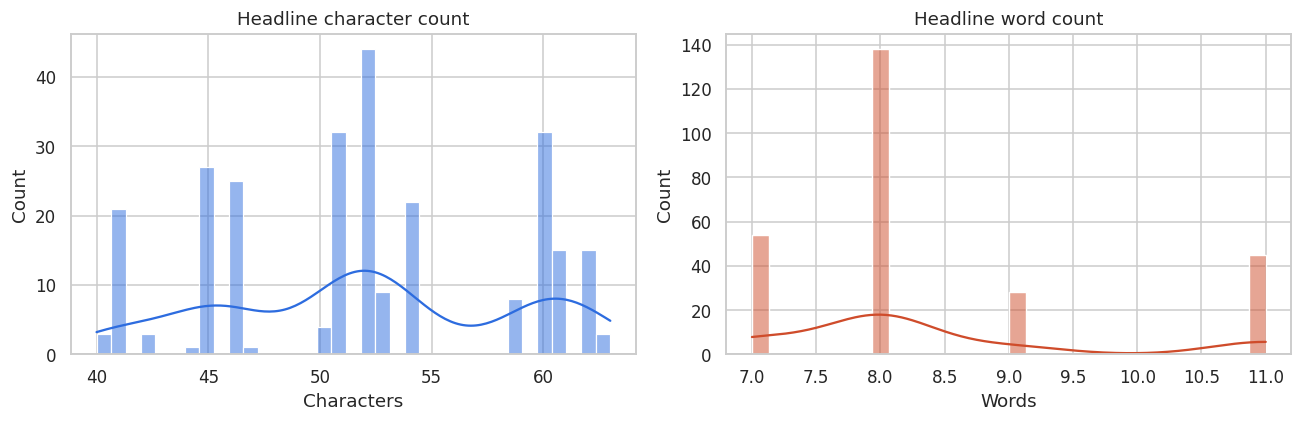

In [4]:
desc = df[["headline_len", "word_count"]].describe(percentiles=[0.05, 0.5, 0.95])
display(desc)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(df["headline_len"], bins=35, kde=True, ax=axes[0], color="#2d6cdf")
axes[0].set_title("Headline character count")
axes[0].set_xlabel("Characters")

sns.histplot(df["word_count"], bins=30, kde=True, ax=axes[1], color="#cf4c2b")
axes[1].set_title("Headline word count")
axes[1].set_xlabel("Words")

plt.tight_layout()
plt.show()

## 3. Publisher concentration

A long tail suggests **selection bias**: a few desks may dominate language style; domain extraction separates corporate inboxes from brand names.

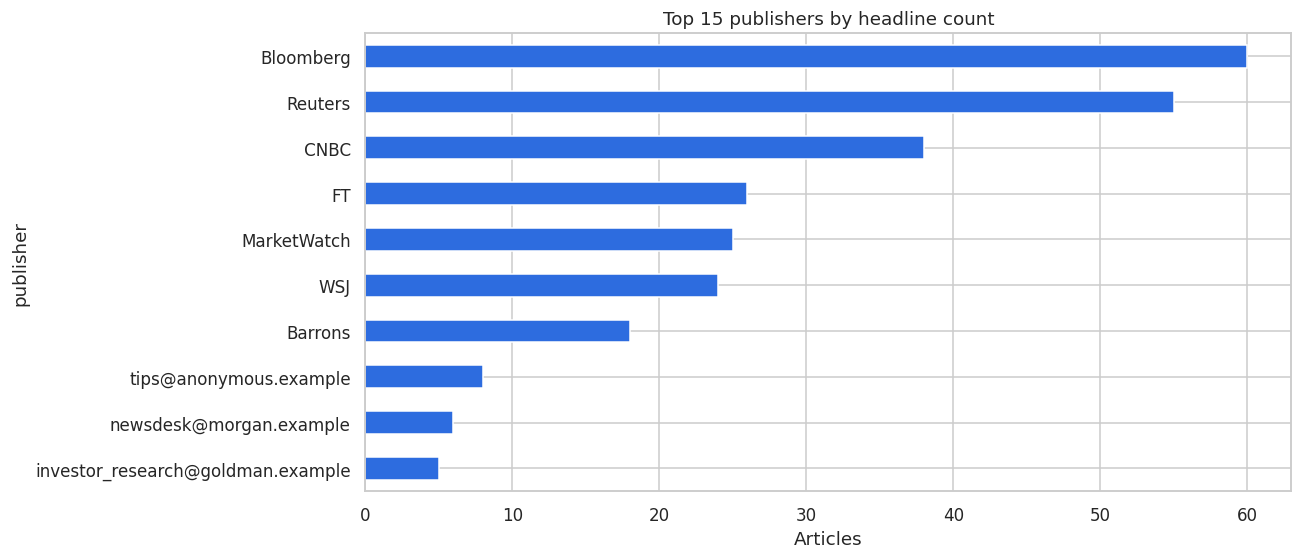

,share
publisher_domain,
Bloomberg,0.226415
Reuters,0.207547
CNBC,0.143396
FT,0.098113
MarketWatch,0.094340
WSJ,0.090566
Barrons,0.067925
anonymous.example,0.030189
morgan.example,0.022642


In [5]:
pub_counts = df["publisher"].fillna("(missing)").value_counts()
top_n = 15

fig, ax = plt.subplots(figsize=(12, max(5, top_n * 0.35)))
pub_counts.head(top_n).sort_values().plot(kind="barh", color="#2d6cdf", ax=ax)
ax.set_title(f"Top {top_n} publishers by headline count")
ax.set_xlabel("Articles")
plt.tight_layout()
plt.show()

publisher_series = df["publisher"].fillna("").astype(str)
email_pat = re.compile(r"^[\w.-]+@[\w.-]+\.\w+$")


def publisher_domain(pub: str) -> str:
    pub = pub.strip()
    if email_pat.match(pub):
        return pub.split("@")[1].lower()
    return pub


df["publisher_domain"] = publisher_series.map(publisher_domain)

domain_share = (
    df["publisher_domain"].value_counts(normalize=True).head(15).rename("share")
)
display(domain_share.to_frame("share"))

## 4. Time series — publication volume

Daily counts reveal **coverage spikes**, often clustered around CPI/FOMC/earnings seasons. The bundled sample injects a synthetic CPI-day cluster for demonstration; with real FNSPID data, overlay known macro dates.

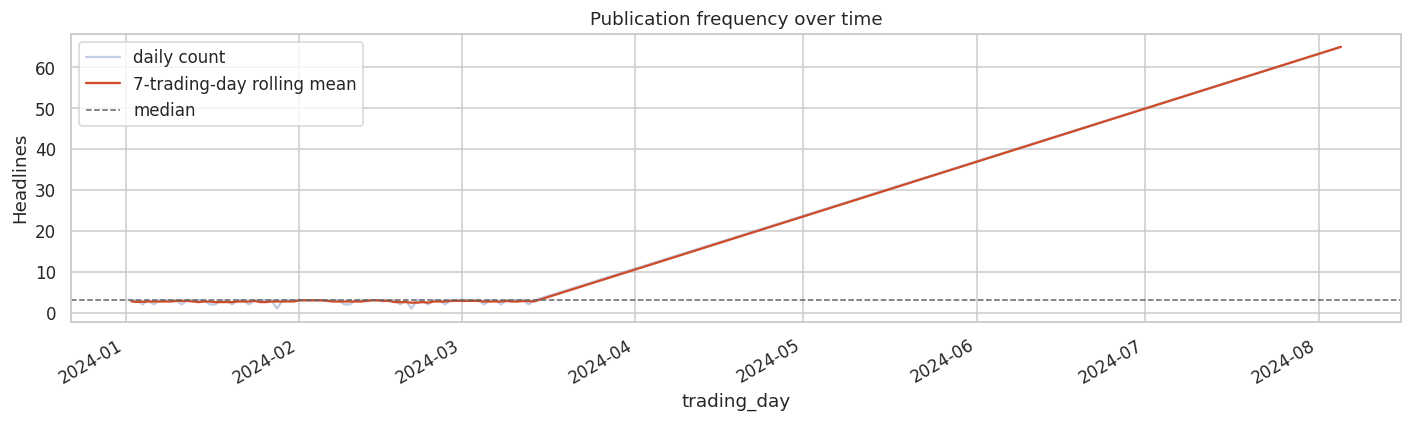

In [6]:
ts = df.dropna(subset=["date"]).copy()
ts["date_norm"] = ts["date"].dt.tz_convert("America/New_York")
ts["trading_day"] = ts["date_norm"].dt.normalize()

daily = ts.groupby("trading_day")["headline"].count().rename("articles")

rolling = daily.rolling("7D", center=True).mean()

fig, ax = plt.subplots(figsize=(13, 4))
daily.plot(ax=ax, alpha=0.35, label="daily count")
rolling.plot(ax=ax, color="#cf4c2b", label="7-trading-day rolling mean")
ax.axhline(daily.median(), color="#666", linestyle="--", linewidth=1, label="median")
ax.legend()
ax.set_title("Publication frequency over time")
ax.set_ylabel("Headlines")
plt.tight_layout()
plt.show()

## 5. Intraday release pattern

If timestamps are trustworthy, spikes around the **premarket open** (~07:30–09:30 ET) and **cash close** are common for desk-driven wires.

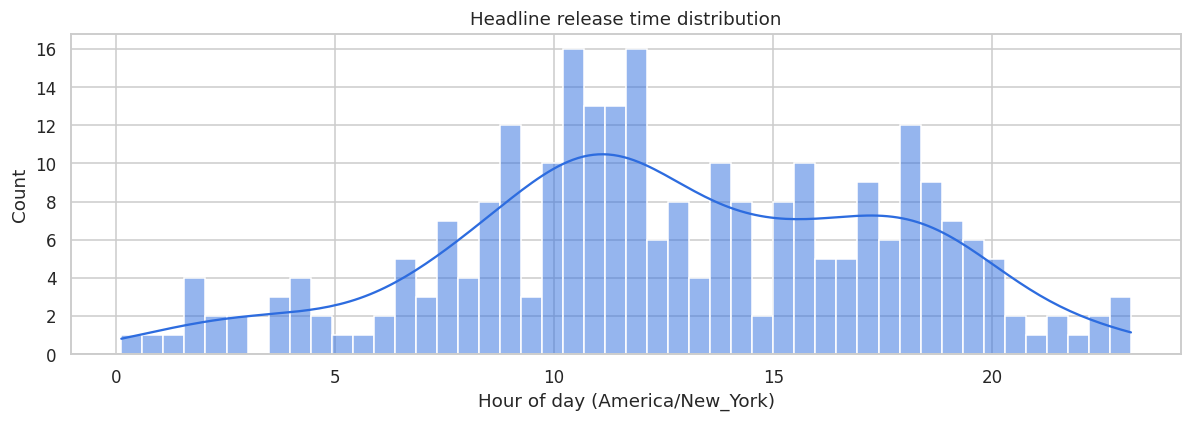

In [7]:
hod = ts["date_norm"].dt.hour.to_numpy(dtype=float)
mom = ts["date_norm"].dt.minute.to_numpy(dtype=float) / 60.0
hour_frac = hod + mom

fig, ax = plt.subplots(figsize=(11, 4))
sns.histplot(hour_frac, bins=48, kde=True, color="#2d6cdf", ax=ax)
ax.set_xlabel("Hour of day (America/New_York)")
ax.set_title("Headline release time distribution")
plt.tight_layout()
plt.show()

## 6. Keyword and topic structure

- **TF–IDF** surfaces desk-specific phrases (price targets, FDA, earnings).
- **LDA** offers a compact topic basis; treat topics as exploratory, not causal labels.

In [8]:
headlines = df["headline"].fillna("").astype(str)

vectorizer = TfidfVectorizer(
    stop_words="english",
    max_features=5000,
    ngram_range=(1, 2),
    min_df=2,
)
try:
    X_tfidf = vectorizer.fit_transform(headlines)
except ValueError as exc:
    print("TF-IDF skipped (likely tiny corpus):", exc)
    X_tfidf = None

if X_tfidf is not None:
    sums = np.asarray(X_tfidf.sum(axis=0)).ravel()
    terms = vectorizer.get_feature_names_out()
    top_idx = np.argsort(-sums)[:25]
    top_terms = pd.DataFrame({"term": terms[top_idx], "tfidf_sum": sums[top_idx]})
    display(top_terms)

,term,tfidf_sum
0,traders,14.745649
1,msft,11.283375
2,cpi,10.996438
3,cpi print,10.996438
4,react cpi,10.996438
5,print focus,10.996438
6,react,10.996438
7,focus,10.996438
8,session traders,10.996438
9,volatile session,10.996438


In [9]:
count_vec = CountVectorizer(
    stop_words="english",
    max_features=3000,
    min_df=2,
)

try:
    X_counts = count_vec.fit_transform(headlines)
except ValueError as exc:
    print("CountVectorizer failed:", exc)
    X_counts = None

if X_counts is not None and X_counts.shape[0] >= 40:
    n_topics = min(8, max(3, len(headlines) // 120))
    lda = LatentDirichletAllocation(
        n_components=n_topics,
        random_state=42,
        learning_method="batch",
        max_iter=40,
        n_jobs=-1,
    )
    lda.fit(X_counts)
    feats = np.array(count_vec.get_feature_names_out())
    topic_rows = []
    for tid, weights in enumerate(lda.components_):
        top_ix = weights.argsort()[-12:][::-1]
        phrases = " | ".join(feats[top_ix])
        topic_rows.append({"topic_id": tid + 1, "top_terms": phrases})
    display(pd.DataFrame(topic_rows))
else:
    print("LDA skipped: need more nonzero rows/terms after vectorization.")

,topic_id,top_terms
0,1,traders | volatile | react | session | print |...
1,2,raise | rises | analysts | outlook | earnings ...
2,3,strong | target | price | growth | cloud | ami...


## 7. Interpretation takeaway

| Finding | Operational meaning |
| --- | --- |
| Tail publishers | Winsorise or stratify sentiment models by outlet family |
| Burst days | Anchor event studies and forward returns to publication day & next session |
| Intraday timing | Signals whether prices react same session vs overnight |
| Repeated phrases | Seeds lexicons (earnings beats, FDA) for domain-aware polarity |

**Limits:** correlations later are associative, not causal; microstructure issues (lookahead, synchronicity) must be audited before live trading ideas.